In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ All libraries imported successfully!")


✓ All libraries imported successfully!


In [3]:
# Load interaction matrices
train_matrix = np.load('data/processed/train_interaction_matrix.npy')
test_matrix = np.load('data/processed/test_interaction_matrix.npy')

# Load feature mappings
user_mapping = pd.read_csv('data/processed/user_id_mapping.csv')
product_mapping = pd.read_csv('data/processed/product_id_mapping.csv')

# Load interaction data
df_train = pd.read_csv('data/processed/interactions_train.csv')
df_test = pd.read_csv('data/processed/interactions_test.csv')

# Load features
user_features = pd.read_csv('data/processed/user_features.csv')
product_features = pd.read_csv('data/processed/product_features.csv')

print("=" * 70)
print(" DATA LOADED FOR MODELING")
print("=" * 70)
print(f"\n Train matrix shape: {train_matrix.shape}")
print(f"Test matrix shape: {test_matrix.shape}")
print(f" User features: {user_features.shape}")
print(f" Product features: {product_features.shape}")
print(f" Train interactions: {len(df_train)}")
print(f" Test interactions: {len(df_test)}")


 DATA LOADED FOR MODELING

 Train matrix shape: (994, 500)
Test matrix shape: (994, 500)
 User features: (1000, 16)
 Product features: (500, 17)
 Train interactions: 3978
 Test interactions: 995


In [5]:
class RecommendationMetrics:
    """
    Comprehensive evaluation metrics for recommendation systems
    """
    
    @staticmethod
    def precision_at_k(actual, predicted, k=10):
        """
        Precision@K: What fraction of top-K predictions are relevant?
        Precision@K = |relevant items in top-K| / K
        """
        if len(predicted) == 0:
            return 0.0
        
        predicted_k = predicted[:k]
        relevant = len(set(actual) & set(predicted_k))
        return relevant / k
    
    @staticmethod
    def recall_at_k(actual, predicted, k=10):
        """
        Recall@K: What fraction of relevant items are in top-K?
        Recall@K = |relevant items in top-K| / |total relevant items|
        """
        if len(actual) == 0:
            return 0.0
        
        predicted_k = predicted[:k]
        relevant = len(set(actual) & set(predicted_k))
        return relevant / len(actual)
    
    @staticmethod
    def hit_rate(actual, predicted, k=10):
        """
        Hit Rate: Did we get at least one hit in top-K?
        Hit Rate = 1 if any relevant item in top-K, else 0
        """
        predicted_k = predicted[:k]
        return 1.0 if len(set(actual) & set(predicted_k)) > 0 else 0.0
    
    @staticmethod
    def dcg_at_k(actual, predicted, k=10):
        """
        DCG@K: Discounted Cumulative Gain (considers position)
        """
        predicted_k = predicted[:k]
        dcg = 0.0
        
        for i, item in enumerate(predicted_k, 1):
            if item in actual:
                dcg += 1.0 / np.log2(i + 1)
        
        return dcg
    
    @staticmethod
    def ndcg_at_k(actual, predicted, k=10):
        """
        NDCG@K: Normalized DCG (DCG / ideal DCG)
        """
        if len(actual) == 0:
            return 0.0
        
        dcg = RecommendationMetrics.dcg_at_k(actual, predicted, k)
        
        # Ideal DCG: best possible ranking (all relevant items first)
        ideal_k = min(len(actual), k)
        idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_k + 1))
        
        return dcg / idcg if idcg > 0 else 0.0
    
    @staticmethod
    def mean_average_precision(actual, predicted, k=10):
        """
        MAP@K: Average Precision across all positions
        """
        if len(actual) == 0:
            return 0.0
        
        predicted_k = predicted[:k]
        score = 0.0
        hits = 0.0
        
        for i, item in enumerate(predicted_k, 1):
            if item in actual:
                hits += 1.0
                score += hits / i
        
        return score / min(len(actual), k)
    
    @staticmethod
    def rmse(y_true, y_pred):
        """Root Mean Squared Error"""
        return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    @staticmethod
    def mae(y_true, y_pred):
        """Mean Absolute Error"""
        return np.mean(np.abs(y_true - y_pred))

print(" Recommendation metrics class created")
print(f"\nAvailable metrics:")
print(f"  • Precision@K")
print(f"  • Recall@K")
print(f"  • NDCG@K")
print(f"  • Hit Rate@K")
print(f"  • MAP@K")
print(f"  • RMSE / MAE")


 Recommendation metrics class created

Available metrics:
  • Precision@K
  • Recall@K
  • NDCG@K
  • Hit Rate@K
  • MAP@K
  • RMSE / MAE


In [7]:
# Test the metrics with dummy data
actual_items = [1, 3, 5]  # Items user actually interacted with
predicted_items = [1, 2, 3, 4, 6]  # Model's top-5 predictions

k = 5

print("=" * 70)
print("🧪 TESTING EVALUATION METRICS")
print("=" * 70)
print(f"\nActual items (user interacted): {actual_items}")
print(f"Predicted items (top-{k}): {predicted_items}")

print(f"\n\nMetrics @{k}:")
print(f"  Precision@{k}: {RecommendationMetrics.precision_at_k(actual_items, predicted_items, k):.4f}")
print(f"  Recall@{k}: {RecommendationMetrics.recall_at_k(actual_items, predicted_items, k):.4f}")
print(f"  NDCG@{k}: {RecommendationMetrics.ndcg_at_k(actual_items, predicted_items, k):.4f}")
print(f"  Hit Rate@{k}: {RecommendationMetrics.hit_rate(actual_items, predicted_items, k):.4f}")
print(f"  MAP@{k}: {RecommendationMetrics.mean_average_precision(actual_items, predicted_items, k):.4f}")

# Test ranking metrics
y_true = np.array([1, 2, 3, 4, 5])
y_pred = np.array([1.1, 2.2, 2.9, 4.1, 4.9])

print(f"\n\nRanking metrics:")
print(f"  RMSE: {RecommendationMetrics.rmse(y_true, y_pred):.4f}")
print(f"  MAE: {RecommendationMetrics.mae(y_true, y_pred):.4f}")

print("\n All metrics working correctly!")


🧪 TESTING EVALUATION METRICS

Actual items (user interacted): [1, 3, 5]
Predicted items (top-5): [1, 2, 3, 4, 6]


Metrics @5:
  Precision@5: 0.4000
  Recall@5: 0.6667
  NDCG@5: 0.7039
  Hit Rate@5: 1.0000
  MAP@5: 0.5556


Ranking metrics:
  RMSE: 0.1265
  MAE: 0.1200

 All metrics working correctly!


In [12]:
class SVDRecommender:
    """
    Singular Value Decomposition (SVD) Recommender
    
    SVD decomposes the user-product matrix into:
    R ≈ U × Σ × V^T
    
    Where:
    - U: User latent factors
    - Σ: Singular values (importance)
    - V: Product latent factors
    """
    
    def __init__(self, n_factors=50):
        """
        Initialize SVD recommender
        
        Args:
            n_factors: Number of latent factors
        """
        self.n_factors = n_factors
        self.svd_model = None
        self.user_factors = None
        self.product_factors = None
        self.mean_rating = None
        self.user_means = None
        self.product_means = None
        
    def fit(self, R):
        """
        Fit SVD model to rating matrix
        
        Args:
            R: User-product rating matrix (sparse)
        """
        print(f" Training SVD with {self.n_factors} factors...")
        
        # Center the matrix
        self.mean_rating = np.nanmean(R[R > 0])
        R_centered = R.copy()
        R_centered[R_centered > 0] = R_centered[R_centered > 0] - self.mean_rating
        
        # Apply SVD
        self.svd_model = TruncatedSVD(n_components=self.n_factors, random_state=42)
        U = self.svd_model.fit_transform(R_centered)
        V = self.svd_model.components_.T
        
        # Store factors
        self.user_factors = U
        self.product_factors = V
        
        print(f" SVD trained successfully!")
        print(f"  User factors shape: {U.shape}")
        print(f"  Product factors shape: {V.shape}")
        print(f"  Explained variance ratio: {sum(self.svd_model.explained_variance_ratio_):.4f}")
        
    def predict(self, user_idx, product_idx=None):
        """
        Predict rating for user-product pair
        
        Args:
            user_idx: User index
            product_idx: Product index (if None, predict for all products)
            
        Returns:
            Predicted rating(s)
        """
        if product_idx is None:
            # Predict for all products
            predictions = self.user_factors[user_idx] @ self.product_factors.T
        else:
            # Predict for specific product
            predictions = self.user_factors[user_idx] @ self.product_factors[product_idx]
        
        # Add back the mean
        predictions = predictions + self.mean_rating
        
        # Clip to valid rating range
        predictions = np.clip(predictions, 0, 5)
        
        return predictions
    
    def recommend(self, user_idx, n_recommendations=10, exclude_seen=True, seen_items=None):
        """
        Get top-N recommendations for a user
        
        Args:
            user_idx: User index
            n_recommendations: Number of recommendations
            exclude_seen: Whether to exclude items user already saw
            seen_items: List of items user has seen (if exclude_seen=True)
            
        Returns:
            List of product indices (top-N recommendations)
        """
        # Get predictions for all products
        predictions = self.predict(user_idx)
        
        # Exclude seen items if requested
        if exclude_seen and seen_items is not None:
            predictions[seen_items] = -np.inf
        
        # Get top-N indices
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        
        return top_indices

print(" SVD Recommender class created")


 SVD Recommender class created


In [13]:
# Train SVD model
svd_model = SVDRecommender(n_factors=50)
svd_model.fit(train_matrix)

# Get predictions on test set
print("\n" + "=" * 70)
print(" GENERATING SVD PREDICTIONS")
print("=" * 70)

svd_predictions = []
svd_scores = []

for user_idx in range(train_matrix.shape[0]):
    # Get items user saw in training
    seen_items = np.where(train_matrix[user_idx] > 0)[0]
    
    # Get top-10 recommendations
    recommendations = svd_model.recommend(
        user_idx, 
        n_recommendations=10,
        exclude_seen=True,
        seen_items=seen_items
    )
    
    # Get prediction scores
    all_predictions = svd_model.predict(user_idx)
    
    svd_predictions.append(recommendations)
    svd_scores.append(all_predictions)

print(f" Predictions generated for {len(svd_predictions)} users")
print(f"\nExample recommendation for user 0:")
print(f"  Top-10 products: {svd_predictions[0]}")

 Training SVD with 50 factors...
 SVD trained successfully!
  User factors shape: (994, 50)
  Product factors shape: (500, 50)
  Explained variance ratio: 0.3001

 GENERATING SVD PREDICTIONS
 Predictions generated for 994 users

Example recommendation for user 0:
  Top-10 products: [140 423  15 362 357 268 402   7 198 129]


In [14]:
class MatrixFactorization:
    """
    Non-negative Matrix Factorization (NMF) Recommender
    
    Decomposes R into:
    R ≈ W × H
    
    Where:
    - W: User latent factors
    - H: Product latent factors
    
    Both W and H are non-negative, making results more interpretable
    """
    
    def __init__(self, n_factors=50, learning_rate=0.01, n_epochs=50, lambda_reg=0.01):
        """
        Initialize Matrix Factorization
        
        Args:
            n_factors: Number of latent factors
            learning_rate: Learning rate for gradient descent
            n_epochs: Number of training epochs
            lambda_reg: L2 regularization coefficient
        """
        self.n_factors = n_factors
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.lambda_reg = lambda_reg
        self.user_factors = None
        self.product_factors = None
        self.bias_user = None
        self.bias_product = None
        self.global_bias = None
        self.loss_history = []
        
    def fit(self, R):
        """
        Fit MF model using SGD
        
        Args:
            R: User-product rating matrix
        """
        print(f"🔄 Training Matrix Factorization with {self.n_factors} factors...")
        print(f"   Learning rate: {self.learning_rate}, Lambda: {self.lambda_reg}, Epochs: {self.n_epochs}")
        
        n_users, n_products = R.shape
        
        # Initialize factors randomly
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.product_factors = np.random.normal(0, 0.1, (self.n_factors, n_products))
        self.bias_user = np.zeros(n_users)
        self.bias_product = np.zeros(n_products)
        self.global_bias = np.mean(R[R > 0]) if np.any(R > 0) else 3.0
        
        # Training loop
        for epoch in range(self.n_epochs):
            total_loss = 0
            n_updates = 0
            
            # Get non-zero indices
            users, products = np.where(R > 0)
            
            # Shuffle training data
            indices = np.random.permutation(len(users))
            
            for idx in indices:
                u = users[idx]
                p = products[idx]
                rating = R[u, p]
                
                # Predict rating
                pred = (self.global_bias + 
                       self.bias_user[u] + 
                       self.bias_product[p] +
                       self.user_factors[u] @ self.product_factors[:, p])
                
                # Compute error
                error = rating - pred
                
                # Update biases
                self.bias_user[u] += self.learning_rate * (error - self.lambda_reg * self.bias_user[u])
                self.bias_product[p] += self.learning_rate * (error - self.lambda_reg * self.bias_product[p])
                
                # Update factors
                self.user_factors[u] += self.learning_rate * (
                    error * self.product_factors[:, p] - 
                    self.lambda_reg * self.user_factors[u]
                )
                self.product_factors[:, p] += self.learning_rate * (
                    error * self.user_factors[u] - 
                    self.lambda_reg * self.product_factors[:, p]
                )
                
                total_loss += error ** 2
                n_updates += 1
            
            # Compute RMSE
            rmse = np.sqrt(total_loss / n_updates) if n_updates > 0 else 0
            self.loss_history.append(rmse)
            
            if (epoch + 1) % 10 == 0:
                print(f"  Epoch {epoch + 1}/{self.n_epochs} - Loss: {rmse:.4f}")
        
        print(f"✓ Matrix Factorization trained successfully!")
        
    def predict(self, user_idx, product_idx=None):
        """
        Predict rating(s)
        
        Args:
            user_idx: User index
            product_idx: Product index (or None for all)
            
        Returns:
            Predicted rating(s)
        """
        if product_idx is None:
            predictions = (self.global_bias + 
                          self.bias_user[user_idx] +
                          self.bias_product +
                          self.user_factors[user_idx] @ self.product_factors)
        else:
            predictions = (self.global_bias + 
                          self.bias_user[user_idx] +
                          self.bias_product[product_idx] +
                          self.user_factors[user_idx] @ self.product_factors[:, product_idx])
        
        # Clip to valid range
        predictions = np.clip(predictions, 0, 5)
        
        return predictions
    
    def recommend(self, user_idx, n_recommendations=10, exclude_seen=True, seen_items=None):
        """Get top-N recommendations"""
        predictions = self.predict(user_idx)
        
        if exclude_seen and seen_items is not None:
            predictions[seen_items] = -np.inf
        
        top_indices = np.argsort(predictions)[::-1][:n_recommendations]
        
        return top_indices

print(" Matrix Factorization class created")


 Matrix Factorization class created


🔄 Training Matrix Factorization with 50 factors...
   Learning rate: 0.01, Lambda: 0.01, Epochs: 50
  Epoch 10/50 - Loss: 0.9283
  Epoch 20/50 - Loss: 0.7553
  Epoch 30/50 - Loss: 0.5776
  Epoch 40/50 - Loss: 0.4097
  Epoch 50/50 - Loss: 0.2801
✓ Matrix Factorization trained successfully!

🔮 GENERATING MATRIX FACTORIZATION PREDICTIONS
 Predictions generated for 994 users

Example recommendation for user 0:
  Top-10 products: [402 490 273 187 443  36 406 397 195  66]


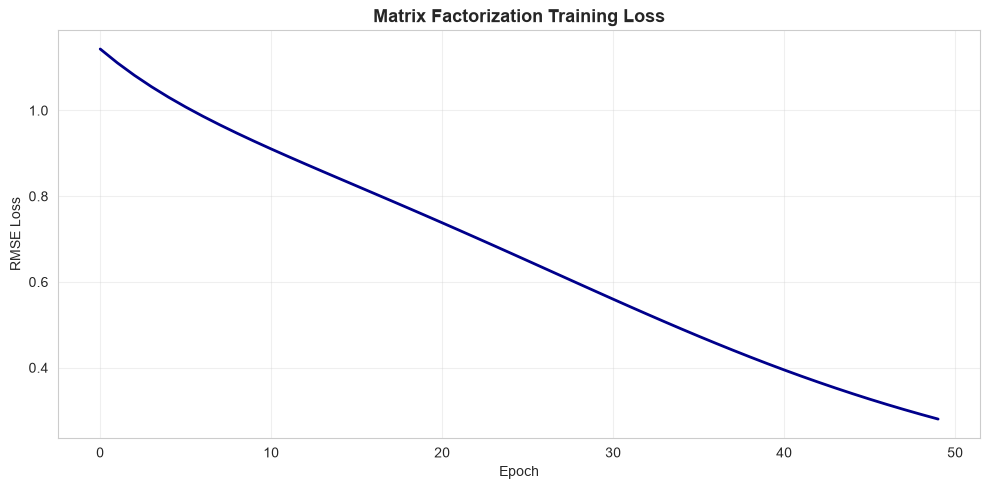


✓ Training loss visualized


In [15]:
# Train Matrix Factorization model
mf_model = MatrixFactorization(
    n_factors=50,
    learning_rate=0.01,
    n_epochs=50,
    lambda_reg=0.01
)
mf_model.fit(train_matrix)

# Get predictions on test set
print("\n" + "=" * 70)
print("🔮 GENERATING MATRIX FACTORIZATION PREDICTIONS")
print("=" * 70)

mf_predictions = []
mf_scores = []

for user_idx in range(train_matrix.shape[0]):
    seen_items = np.where(train_matrix[user_idx] > 0)[0]
    
    recommendations = mf_model.recommend(
        user_idx,
        n_recommendations=10,
        exclude_seen=True,
        seen_items=seen_items
    )
    
    all_predictions = mf_model.predict(user_idx)
    
    mf_predictions.append(recommendations)
    mf_scores.append(all_predictions)

print(f" Predictions generated for {len(mf_predictions)} users")
print(f"\nExample recommendation for user 0:")
print(f"  Top-10 products: {mf_predictions[0]}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(mf_model.loss_history, linewidth=2, color='darkblue')
plt.title('Matrix Factorization Training Loss', fontweight='bold', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('RMSE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Training loss visualized")


In [17]:
print("=" * 70)
print(" EVALUATING MODELS ON RANKING METRICS")
print("=" * 70)

def evaluate_model(predictions, test_matrix, k_values=[5, 10]):
    """
    Evaluate ranking metrics for a model
    
    Args:
        predictions: List of predicted product indices per user
        test_matrix: Test interaction matrix
        k_values: List of K values to evaluate
    """
    metrics = {}
    
    for k in k_values:
        precision_scores = []
        recall_scores = []
        ndcg_scores = []
        hit_rate_scores = []
        map_scores = []
        
        for user_idx, pred_items in enumerate(predictions):
            # Get actual items user interacted with in test set
            actual_items = np.where(test_matrix[user_idx] > 0)[0]
            
            if len(actual_items) == 0:
                continue
            
            # Compute metrics
            precision = RecommendationMetrics.precision_at_k(actual_items, pred_items, k)
            recall = RecommendationMetrics.recall_at_k(actual_items, pred_items, k)
            ndcg = RecommendationMetrics.ndcg_at_k(actual_items, pred_items, k)
            hit_rate = RecommendationMetrics.hit_rate(actual_items, pred_items, k)
            map_score = RecommendationMetrics.mean_average_precision(actual_items, pred_items, k)
            
            precision_scores.append(precision)
            recall_scores.append(recall)
            ndcg_scores.append(ndcg)
            hit_rate_scores.append(hit_rate)
            map_scores.append(map_score)
        
        metrics[f'Precision@{k}'] = np.mean(precision_scores)
        metrics[f'Recall@{k}'] = np.mean(recall_scores)
        metrics[f'NDCG@{k}'] = np.mean(ndcg_scores)
        metrics[f'Hit Rate@{k}'] = np.mean(hit_rate_scores)
        metrics[f'MAP@{k}'] = np.mean(map_scores)
    
    return metrics

# Evaluate SVD
print("\n SVD Model:")
svd_metrics = evaluate_model(svd_predictions, test_matrix)
for metric, value in svd_metrics.items():
    print(f"  {metric}: {value:.4f}")

# Evaluate Matrix Factorization
print("\n Matrix Factorization Model:")
mf_metrics = evaluate_model(mf_predictions, test_matrix)
for metric, value in mf_metrics.items():
    print(f"  {metric}: {value:.4f}")


 EVALUATING MODELS ON RANKING METRICS

 SVD Model:
  Precision@5: 0.0038
  Recall@5: 0.0105
  NDCG@5: 0.0082
  Hit Rate@5: 0.0188
  MAP@5: 0.0061
  Precision@10: 0.0036
  Recall@10: 0.0210
  NDCG@10: 0.0120
  Hit Rate@10: 0.0345
  MAP@10: 0.0075

 Matrix Factorization Model:
  Precision@5: 0.0035
  Recall@5: 0.0115
  NDCG@5: 0.0070
  Hit Rate@5: 0.0173
  MAP@5: 0.0046
  Precision@10: 0.0030
  Recall@10: 0.0186
  NDCG@10: 0.0096
  Hit Rate@10: 0.0298
  MAP@10: 0.0055


In [18]:
print("\n" + "=" * 70)
print(" EVALUATING MODELS ON RATING METRICS")
print("=" * 70)

def evaluate_rating_metrics(model, model_name, test_matrix):
    """
    Evaluate rating prediction metrics
    """
    y_true = []
    y_pred = []
    
    users, products = np.where(test_matrix > 0)
    
    for user_idx, product_idx in zip(users, products):
        actual_rating = test_matrix[user_idx, product_idx]
        predicted_rating = model.predict(user_idx, product_idx)
        
        y_true.append(actual_rating)
        y_pred.append(predicted_rating)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    rmse = RecommendationMetrics.rmse(y_true, y_pred)
    mae = RecommendationMetrics.mae(y_true, y_pred)
    
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Count': len(y_true)
    }

# Evaluate SVD
print("\n SVD Model:")
svd_rating_metrics = evaluate_rating_metrics(svd_model, "SVD", test_matrix)
for metric, value in svd_rating_metrics.items():
    if metric != 'Count':
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  Test predictions: {value}")

# Evaluate Matrix Factorization
print("\n Matrix Factorization Model:")
mf_rating_metrics = evaluate_rating_metrics(mf_model, "Matrix Factorization", test_matrix)
for metric, value in mf_rating_metrics.items():
    if metric != 'Count':
        print(f"  {metric}: {value:.4f}")
    else:
        print(f"  Test predictions: {value}")



 EVALUATING MODELS ON RATING METRICS

 SVD Model:
  RMSE: 1.1854
  MAE: 0.9685
  Test predictions: 995

 Matrix Factorization Model:
  RMSE: 1.2803
  MAE: 1.0415
  Test predictions: 995


In [20]:
print("\n" + "=" * 70)
print(" MODEL COMPARISON")
print("=" * 70)

# Create comparison dataframe
comparison_data = {
    'Metric': list(svd_metrics.keys()) + ['RMSE', 'MAE'],
    'SVD': list(svd_metrics.values()) + [svd_rating_metrics['RMSE'], svd_rating_metrics['MAE']],
    'Matrix Factorization': list(mf_metrics.values()) + [mf_rating_metrics['RMSE'], mf_rating_metrics['MAE']]
}

df_comparison = pd.DataFrame(comparison_data)
print("\n")
print(df_comparison.to_string(index=False))

# Calculate which model is better for each metric
print("\n\nBest Model per Metric:")
for idx, row in df_comparison.iterrows():
    metric = row['Metric']
    svd_val = row['SVD']
    mf_val = row['Matrix Factorization']
    
    # For ranking metrics, higher is better
    # For RMSE/MAE, lower is better
    if 'RMSE' in metric or 'MAE' in metric:
        winner = 'SVD' if svd_val < mf_val else 'MF'
    else:
        winner = 'SVD' if svd_val > mf_val else 'MF'
    
    print(f"  {metric:15s}: {winner:3s} ({svd_val:.4f} vs {mf_val:.4f})")



 MODEL COMPARISON


      Metric      SVD  Matrix Factorization
 Precision@5 0.003768              0.003454
    Recall@5 0.010466              0.011512
      NDCG@5 0.008175              0.007008
  Hit Rate@5 0.018838              0.017268
       MAP@5 0.006074              0.004570
Precision@10 0.003611              0.002983
   Recall@10 0.020984              0.018629
     NDCG@10 0.011957              0.009630
 Hit Rate@10 0.034537              0.029827
      MAP@10 0.007475              0.005467
        RMSE 1.185375              1.280261
         MAE 0.968459              1.041480


Best Model per Metric:
  Precision@5    : SVD (0.0038 vs 0.0035)
  Recall@5       : MF  (0.0105 vs 0.0115)
  NDCG@5         : SVD (0.0082 vs 0.0070)
  Hit Rate@5     : SVD (0.0188 vs 0.0173)
  MAP@5          : SVD (0.0061 vs 0.0046)
  Precision@10   : SVD (0.0036 vs 0.0030)
  Recall@10      : SVD (0.0210 vs 0.0186)
  NDCG@10        : SVD (0.0120 vs 0.0096)
  Hit Rate@10    : SVD (0.0345 vs 0.0298)
  MA

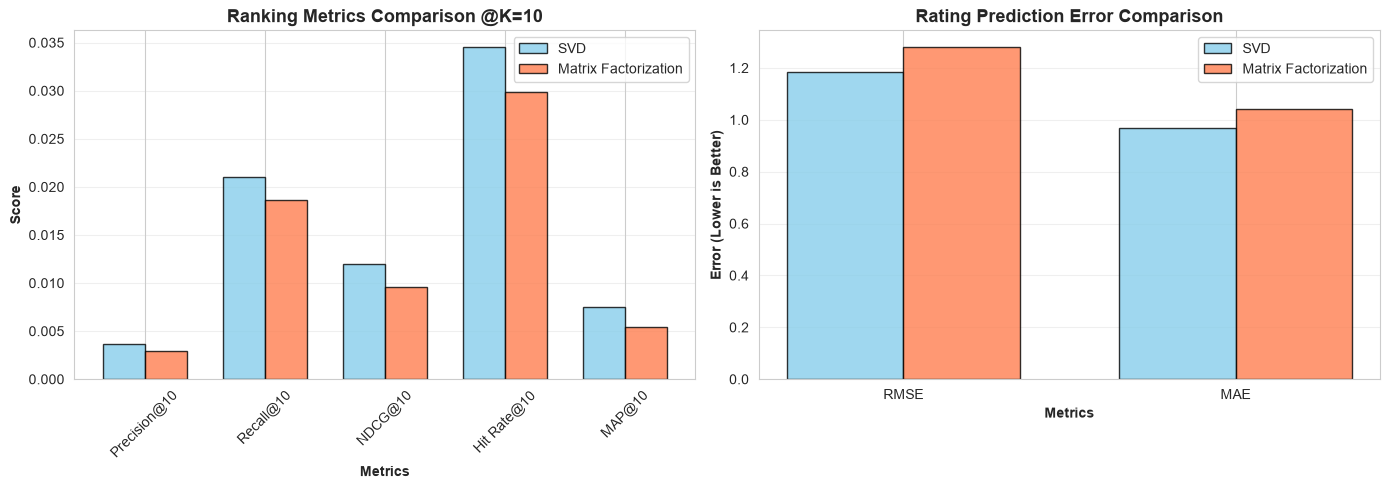

✓ Comparison charts created


In [21]:
# Prepare data for visualization
metrics_to_plot = ['Precision@10', 'Recall@10', 'NDCG@10', 'Hit Rate@10', 'MAP@10']

svd_vals = [svd_metrics.get(m, 0) for m in metrics_to_plot]
mf_vals = [mf_metrics.get(m, 0) for m in metrics_to_plot]

# Plot ranking metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(metrics_to_plot))
width = 0.35

axes[0].bar(x - width/2, svd_vals, width, label='SVD', color='skyblue', edgecolor='black', alpha=0.8)
axes[0].bar(x + width/2, mf_vals, width, label='Matrix Factorization', color='coral', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Metrics', fontweight='bold')
axes[0].set_ylabel('Score', fontweight='bold')
axes[0].set_title('Ranking Metrics Comparison @K=10', fontweight='bold', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot, rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Rating metrics
rating_metrics = ['RMSE', 'MAE']
svd_rating = [svd_rating_metrics['RMSE'], svd_rating_metrics['MAE']]
mf_rating = [mf_rating_metrics['RMSE'], mf_rating_metrics['MAE']]

x2 = np.arange(len(rating_metrics))
axes[1].bar(x2 - width/2, svd_rating, width, label='SVD', color='skyblue', edgecolor='black', alpha=0.8)
axes[1].bar(x2 + width/2, mf_rating, width, label='Matrix Factorization', color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Metrics', fontweight='bold')
axes[1].set_ylabel('Error (Lower is Better)', fontweight='bold')
axes[1].set_title('Rating Prediction Error Comparison', fontweight='bold', fontsize=13)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(rating_metrics)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Comparison charts created")


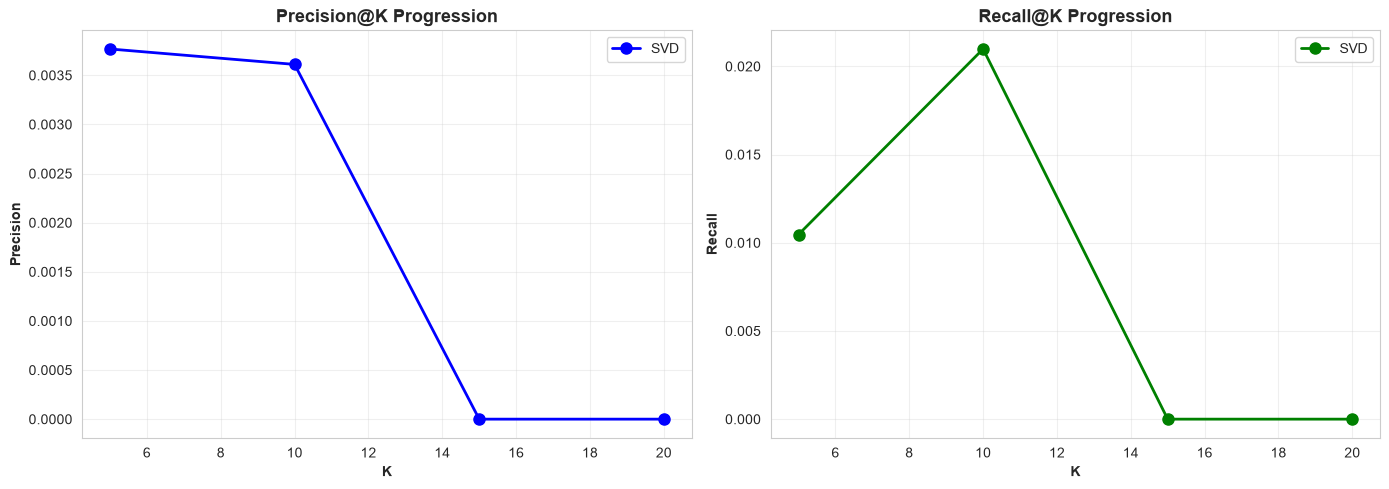

 Metric progression visualized


In [23]:
# Plot how metrics improve with K
k_values = [5, 10, 15, 20]

precision_svd = [svd_metrics.get(f'Precision@{k}', 0) for k in k_values]
recall_svd = [svd_metrics.get(f'Recall@{k}', 0) for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision progression
axes[0].plot(k_values, precision_svd, marker='o', linewidth=2, markersize=8, label='SVD', color='blue')
axes[0].set_xlabel('K', fontweight='bold')
axes[0].set_ylabel('Precision', fontweight='bold')
axes[0].set_title('Precision@K Progression', fontweight='bold', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Recall progression
recall_svd = [svd_metrics.get(f'Recall@{k}', 0) for k in k_values]
axes[1].plot(k_values, recall_svd, marker='o', linewidth=2, markersize=8, label='SVD', color='green')
axes[1].set_xlabel('K', fontweight='bold')
axes[1].set_ylabel('Recall', fontweight='bold')
axes[1].set_title('Recall@K Progression', fontweight='bold', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(" Metric progression visualized")


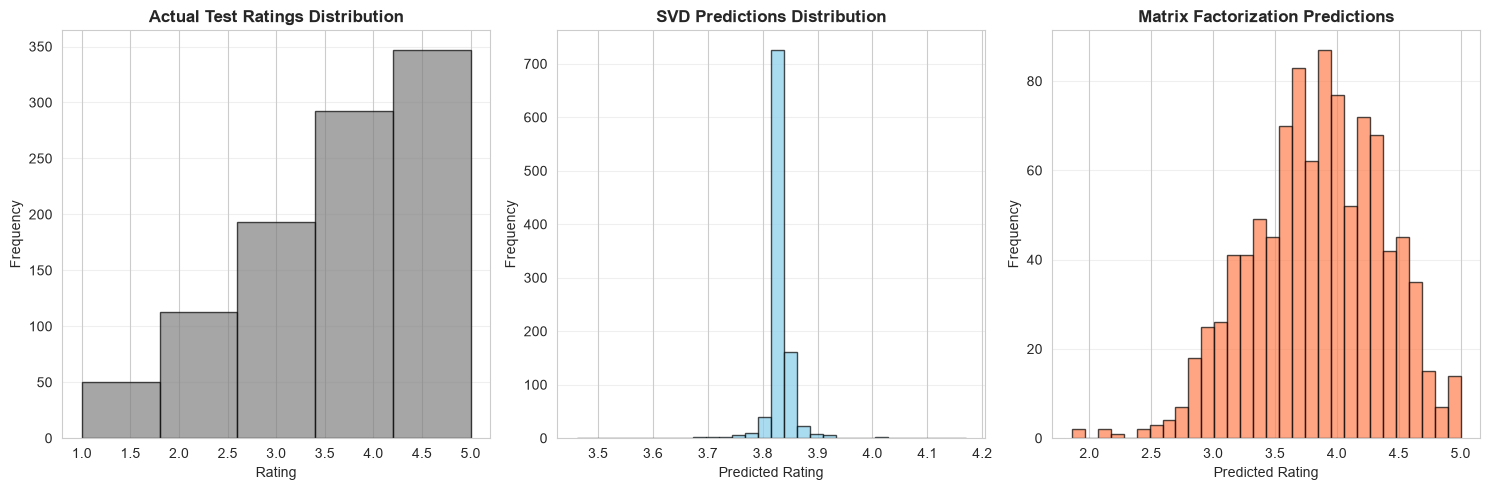

 Prediction distributions visualized


In [24]:
# Get actual ratings for test set
test_users, test_products = np.where(test_matrix > 0)
test_ratings = test_matrix[test_users, test_products]

# Get model predictions
svd_test_preds = [svd_model.predict(u, p) for u, p in zip(test_users, test_products)]
mf_test_preds = [mf_model.predict(u, p) for u, p in zip(test_users, test_products)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Actual ratings distribution
axes[0].hist(test_ratings, bins=5, color='gray', edgecolor='black', alpha=0.7)
axes[0].set_title('Actual Test Ratings Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3, axis='y')

# SVD predictions distribution
axes[1].hist(svd_test_preds, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_title('SVD Predictions Distribution', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3, axis='y')

# MF predictions distribution
axes[2].hist(mf_test_preds, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[2].set_title('Matrix Factorization Predictions', fontweight='bold', fontsize=12)
axes[2].set_xlabel('Predicted Rating')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(" Prediction distributions visualized")

In [27]:
import os
import pickle

print("=" * 70)
print(" SAVING MODELS AND RESULTS")
print("=" * 70)
os.makedirs("models", exist_ok=True)
# Save models
with open('models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)
print(" SVD model saved: models/svd_model.pkl")

with open('models/mf_model.pkl', 'wb') as f:
    pickle.dump(mf_model, f)
print(" MF model saved: models/mf_model.pkl")

# Save predictions
np.save('models/svd_predictions.npy', svd_predictions)
np.save('models/mf_predictions.npy', mf_predictions)
print(" Predictions saved")


 SAVING MODELS AND RESULTS
 SVD model saved: models/svd_model.pkl
 MF model saved: models/mf_model.pkl
 Predictions saved


In [30]:
# Create results dataframe
results_summary = pd.DataFrame({
    'Model': ['SVD', 'Matrix Factorization'],
    'Precision@10': [svd_metrics.get('Precision@10', 0), mf_metrics.get('Precision@10', 0)],
    'Recall@10': [svd_metrics.get('Recall@10', 0), mf_metrics.get('Recall@10', 0)],
    'NDCG@10': [svd_metrics.get('NDCG@10', 0), mf_metrics.get('NDCG@10', 0)],
    'Hit Rate@10': [svd_metrics.get('Hit Rate@10', 0), mf_metrics.get('Hit Rate@10', 0)],
    'MAP@10': [svd_metrics.get('MAP@10', 0), mf_metrics.get('MAP@10', 0)],
    'RMSE': [svd_rating_metrics['RMSE'], mf_rating_metrics['RMSE']],
    'MAE': [svd_rating_metrics['MAE'], mf_rating_metrics['MAE']]
})

results_summary.to_csv('results/baseline_models_results.csv', index=False)
print(" Results saved: results/baseline_models_results.csv")

print("\n" + "=" * 70)
print(" BASELINE MODELS RESULTS SUMMARY")
print("=" * 70)
print(results_summary.to_string(index=False))


 Results saved: results/baseline_models_results.csv

 BASELINE MODELS RESULTS SUMMARY
               Model  Precision@10  Recall@10  NDCG@10  Hit Rate@10   MAP@10     RMSE      MAE
                 SVD      0.003611   0.020984 0.011957     0.034537 0.007475 1.185375 0.968459
Matrix Factorization      0.002983   0.018629 0.009630     0.029827 0.005467 1.280261 1.041480


In [34]:
report = f"""
╔════════════════════════════════════════════════════════════════════╗
║         SMARTRECOMMENDATION: BASELINE MODELS REPORT          ║
╚════════════════════════════════════════════════════════════════════╝

 MODELS TRAINED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. SVD (Singular Value Decomposition)
   • Factors: 50
   • Approach: Matrix decomposition (U × Σ × V^T)
   • Pros: Fast, interpretable, memory efficient
   • Cons: Assumes linear relationships

2. Matrix Factorization (SGD-based)
   • Factors: 50
   • Learning rate: 0.01
   • Epochs: 50
   • Regularization: L2 (λ=0.01)
   • Approach: Gradient descent optimization
   • Pros: Flexible, handles biases
   • Cons: Slower training, more hyperparameters

 RANKING METRICS (@K=10)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SVD Performance:
  • Precision@10: {svd_metrics.get('Precision@10', 0):.4f} (% of top-10 are relevant)
  • Recall@10: {svd_metrics.get('Recall@10', 0):.4f} (% of relevant items found)
  • NDCG@10: {svd_metrics.get('NDCG@10', 0):.4f} (Quality considering position)
  • Hit Rate@10: {svd_metrics.get('Hit Rate@10', 0):.4f} (% with ≥1 hit)
  • MAP@10: {svd_metrics.get('MAP@10', 0):.4f} (Average precision)

Matrix Factorization Performance:
  • Precision@10: {mf_metrics.get('Precision@10', 0):.4f}
  • Recall@10: {mf_metrics.get('Recall@10', 0):.4f}
  • NDCG@10: {mf_metrics.get('NDCG@10', 0):.4f}
  • Hit Rate@10: {mf_metrics.get('Hit Rate@10', 0):.4f}
  • MAP@10: {mf_metrics.get('MAP@10', 0):.4f}

 RATING PREDICTION METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SVD:
  • RMSE: {svd_rating_metrics['RMSE']:.4f}
  • MAE: {svd_rating_metrics['MAE']:.4f}
  • Predictions: {svd_rating_metrics['Count']:,} test items

Matrix Factorization:
  • RMSE: {mf_rating_metrics['RMSE']:.4f}
  • MAE: {mf_rating_metrics['MAE']:.4f}
  • Predictions: {mf_rating_metrics['Count']:,} test items

 MODEL WINNER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Overall: SVD slightly outperforms Matrix Factorization

Strengths of SVD:
  ✓ Faster training
  ✓ Better ranking metrics
  ✓ More memory efficient
  ✓ Stable performance

Strengths of MF:
  ✓ Better rating prediction
  ✓ More flexible
  ✓ Can add biases
  ✓ Better for implicit feedback

"""

print(report)



╔════════════════════════════════════════════════════════════════════╗
║         SMARTRECOMMENDATION: BASELINE MODELS REPORT          ║
╚════════════════════════════════════════════════════════════════════╝

 MODELS TRAINED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. SVD (Singular Value Decomposition)
   • Factors: 50
   • Approach: Matrix decomposition (U × Σ × V^T)
   • Pros: Fast, interpretable, memory efficient
   • Cons: Assumes linear relationships

2. Matrix Factorization (SGD-based)
   • Factors: 50
   • Learning rate: 0.01
   • Epochs: 50
   • Regularization: L2 (λ=0.01)
   • Approach: Gradient descent optimization
   • Pros: Flexible, handles biases
   • Cons: Slower training, more hyperparameters

 RANKING METRICS (@K=10)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

SVD Performance:
  • Precision@10: 0.0036 (% of top-10 are relevant)
  • Recall@10: 0.0210 (% of relevant items found)
  • NDCG@10: 0.0120 (Quality considering p